# **1. Import Library**

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nltk
from google.colab import drive
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizerFast
from transformers import TFRobertaModel
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files
import shutil
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.metrics import classification_report
from tf_keras.src.callbacks import EarlyStopping
from tf_keras.optimizers import experimental as tfa_opt

seed=42

In [2]:
df = pd.read_csv('daftar_topik_ldanew2.csv')

df.head()

,Unnamed: 0.1,Unnamed: 0,userName,content,score,at,appVersion,casefolding,text_cleaned,slang,stopwords,sentiment_label,word_count,dominant_topic,char_len,slang_len,over_repeated,repeated_words,repeated_count,slang2
0,0,0,Trie Sefita,nyari driver sampe setengah jam lebih ga dapet...,1,2021-11-07 07:33:42,4.30.1,nyari driver sampe setengah jam lebih ga dapet...,nyari driver sampe setengah jam lebih ga dapet...,mencari driver sampai setengah jam lebih tidak...,mencari driver setengah jam lebih tidak dapat ...,negative,11,1,79,12,False,[],0,mencari driver sampai setengah jam lebih tidak...
1,1,1,Erpi Anto,Sistem gojek aneh aplikasi gojek g pernah di p...,1,2022-10-17 22:38:57,4.54.2,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek g pernah di p...,sistem gojek aneh aplikasi gojek tidak pernah ...,sistem gojek aneh aplikasi gojek tidak pernah ...,negative,43,2,307,47,True,[],0,sistem gojek aneh aplikasi gojek tidak pernah ...
2,2,2,Ismoy12,Kepada yth pimpinan gojek akhir akhir ini saya...,2,2022-01-23 09:24:36,4.31.1,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yth pimpinan gojek akhir akhir ini saya...,kepada yang terhormat pimpinan gojek akhir akh...,terhormat pimpinan gojek akhir akhir susah sek...,negative,18,1,160,24,False,[],0,kepada yang terhormat pimpinan gojek akhir akh...
3,3,3,azyzs downloader,WAHAI KASTAMER ANDA SADAR NGGAK MEMBERI BINTAN...,1,2023-11-06 07:38:03,4.31.1,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar nggak memberi bintan...,wahai kastamer anda sadar enggak memberi binta...,wahai kastamer sadar enggak memberi bintang ba...,negative,52,1,482,68,False,[],0,wahai kastamer anda sadar tidak memberi bintan...
4,4,4,Ade Sofyan,Kecewa pesanan saya tidak lengkap saya mesen m...,1,2023-06-01 05:16:44,4.60.1,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya mesen m...,kecewa pesanan saya tidak lengkap saya memesan...,kecewa pesanan tidak lengkap memesan makanan d...,negative,15,1,132,20,False,[],0,kecewa pesanan saya tidak lengkap saya memesan...


In [3]:
df = df[['slang2', 'sentiment_label']]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   slang2           19991 non-null  object
 1   sentiment_label  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [5]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
negative,10000
positive,10000


In [6]:
df['sentiment_label'] = df['sentiment_label'].map({'negative':0,'positive':1})

df['sentiment_label'].value_counts()

,count
sentiment_label,
0,10000
1,10000


In [7]:
x = df['slang2'].values
y = df['sentiment_label'].values

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=seed)

X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.1 / 0.9, stratify=y_temp, random_state=seed)


In [9]:
y_train_le = y_train.copy()
y_valid_le = y_valid.copy()
y_test_le = y_test.copy()

In [10]:
ohe = preprocessing.OneHotEncoder()
y_train = ohe.fit_transform(np.array(y_train).reshape(-1, 1)).toarray()
y_valid = ohe.fit_transform(np.array(y_valid).reshape(-1, 1)).toarray()
y_test = ohe.fit_transform(np.array(y_test).reshape(-1, 1)).toarray()

In [11]:
print(f"TRAINING DATA: {X_train.shape[0]}\nVALIDATION DATA: {X_valid.shape[0]}\nTESTING DATA: {X_test.shape[0]}" )

TRAINING DATA: 15999
VALIDATION DATA: 2001
TESTING DATA: 2000


In [12]:
tokenizer_roberta = RobertaTokenizerFast.from_pretrained("roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [12]:
tokenizer_roberta_indo = RobertaTokenizerFast.from_pretrained("cahya/roberta-base-indonesian-1.5G")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

In [13]:
MAX_LEN=128

In [14]:
def tokenize_roberta(data, max_len):
    input_ids = []
    attention_masks = []

    for text in data:
        encoded = tokenizer_roberta.encode_plus(
            str(text),
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)


In [15]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)

In [16]:
train_input_ids, train_attention_masks = tokenize_roberta(X_train, MAX_LEN)
val_input_ids, val_attention_masks = tokenize_roberta(X_valid, MAX_LEN)
test_input_ids, test_attention_masks = tokenize_roberta(X_test, MAX_LEN)

In [17]:
class WarmupLinearDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps, end_lr=0.0, name="WarmupLinearDecay"):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.end_lr = end_lr
        self.name = name

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        warmup_lr = self.initial_lr * (step / self.warmup_steps)
        decay_lr = self.initial_lr - (
            (self.initial_lr - self.end_lr)
            * ((step - self.warmup_steps) /
               (self.total_steps - self.warmup_steps))
        )

        return tf.cond(step < self.warmup_steps,
                       lambda: warmup_lr,
                       lambda: decay_lr)

    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "end_lr": self.end_lr,
            "name": self.name,
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
)

In [19]:
print(y_train[:5])
print(y_train.shape)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
(15999, 2)


In [21]:
BATCH_SIZE = 32
EPOCHS = 8

In [22]:
train_steps_per_epoch = len(train_input_ids) // BATCH_SIZE
total_steps = train_steps_per_epoch * EPOCHS

# **RoBERTa-base VS RoBERTa-Base-Indonesian 1.5G**

# 1. RoBERTa-base

In [23]:
roberta_model = TFRobertaModel.from_pretrained("roberta-base", from_pt=True)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.decoder.weight', 'lm_head.dense.bias']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint 

In [24]:
def create_model(roberta_model, max_len=MAX_LEN):

    opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_masks = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    outputs = roberta_model([input_ids, attention_masks])
    pooled_output = outputs[1]

    sentiment_output = tf.keras.layers.Dense(2, activation='softmax', name="sentiment_output")(pooled_output)

    model = tf.keras.models.Model(
        inputs=[input_ids, attention_masks],
        outputs=sentiment_output
    )

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])

    return model

In [25]:
model = create_model(roberta_model, MAX_LEN)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1246456   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   32         'attention_mask[0][0]']      
                             hidden_state=(None, 128, 7                                       

In [26]:
history_roberta = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 486s 826ms/step - loss: 0.3841 - categorical_accuracy: 0.8409 - val_loss: 0.2767 - val_categorical_accuracy: 0.8966
Epoch 2/8
500/500 [==============================] - 400s 800ms/step - loss: 0.2921 - categorical_accuracy: 0.8936 - val_loss: 0.2631 - val_categorical_accuracy: 0.9005
Epoch 3/8
500/500 [==============================] - 399s 799ms/step - loss: 0.2600 - categorical_accuracy: 0.9097 - val_loss: 0.2505 - val_categorical_accuracy: 0.9115
Epoch 4/8
500/500 [==============================] - 399s 799ms/step - loss: 0.2388 - categorical_accuracy: 0.9198 - val_loss: 0.2633 - val_categorical_accuracy: 0.9070
Epoch 5/8
500/500 [==============================] - 399s 798ms/step - loss: 0.2178 - categorical_accuracy: 0.9268 - val_loss: 0.2624 - val_categorical_accuracy: 0.9080


In [27]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 19s 255ms/step


In [28]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

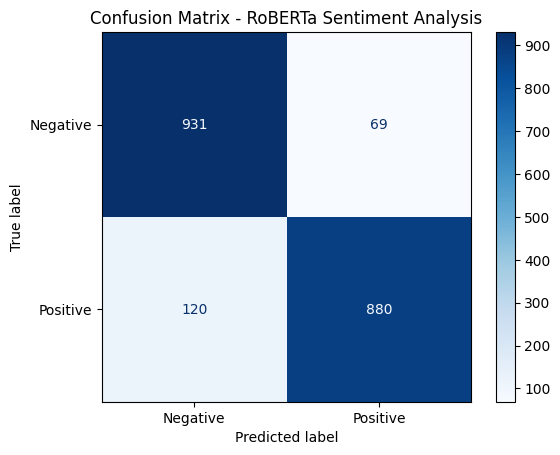

In [29]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [30]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Negative', 'Positive'], digits=4))

	Classification Report for RoBERTa:

               precision    recall  f1-score   support

    Negative     0.8858    0.9310    0.9078      1000
    Positive     0.9273    0.8800    0.9030      1000

   micro avg     0.9055    0.9055    0.9055      2000
   macro avg     0.9066    0.9055    0.9054      2000
weighted avg     0.9066    0.9055    0.9054      2000
 samples avg     0.9055    0.9055    0.9055      2000



# 2. RoBERTa-Base-Indonesian 1.5G

## **Baseline RoBERTa (RoBERTa Batch Size 32, Learning Rate 1e-5, Adam Optimizer(RoBERTa-Base-Indonesian 1.5G))**

In [ ]:
def create_model(roberta_model, max_len=MAX_LEN):

    opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_masks = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    outputs = roberta_model([input_ids, attention_masks])
    pooled_output = outputs[1]

    sentiment_output = tf.keras.layers.Dense(2, activation='softmax', name="sentiment_output")(pooled_output)

    model = tf.keras.models.Model(
        inputs=[input_ids, attention_masks],
        outputs=sentiment_output
    )

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])

    return model


In [ ]:
model = create_model(indo_roberta_model, MAX_LEN)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1259781   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   12         'attention_mask[0][0]']      
                             hidden_state=(None, 128, 7                                       

In [ ]:
history_indo_roberta = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 468s 835ms/step - loss: 0.2886 - categorical_accuracy: 0.8937 - val_loss: 0.2331 - val_categorical_accuracy: 0.9290
Epoch 2/8
500/500 [==============================] - 409s 817ms/step - loss: 0.2247 - categorical_accuracy: 0.9262 - val_loss: 0.2339 - val_categorical_accuracy: 0.9265
Epoch 3/8
500/500 [==============================] - 408s 816ms/step - loss: 0.1919 - categorical_accuracy: 0.9366 - val_loss: 0.2584 - val_categorical_accuracy: 0.9185


In [ ]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 20s 260ms/step


In [ ]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

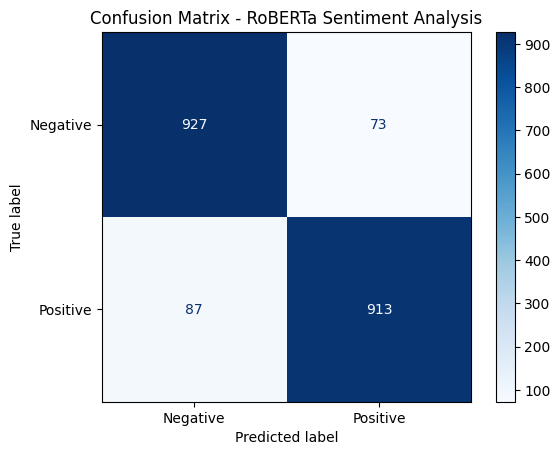

In [ ]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [ ]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Negative', 'Positive'], digits=4))

	Classification Report for RoBERTa:

               precision    recall  f1-score   support

    Negative     0.9142    0.9270    0.9206      1000
    Positive     0.9260    0.9130    0.9194      1000

   micro avg     0.9200    0.9200    0.9200      2000
   macro avg     0.9201    0.9200    0.9200      2000
weighted avg     0.9201    0.9200    0.9200      2000
 samples avg     0.9200    0.9200    0.9200      2000



In [33]:
def predict_sentiment(text):
    tokens = tokenizer_roberta_indo(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

    predictions = model.predict([tokens['input_ids'], tokens['attention_mask']], verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0]

    label_map = {0: "Negatif", 1: "Positif"}

    return label_map[predicted_class], predictions[0]

In [ ]:
tests = [
    "layanannya buruk sekali, bikin emosi",
    "fiturnya sering error dan tidak bisa dipakai",
    "saya sangat kecewa, aplikasinya mengecewakan",
    "respon customer service lama banget",
    "aplikasi makin jelek setelah update terbaru",
    "fitur pembayaran tidak berfungsi, parah",
    "pengalaman paling buruk memakai aplikasi ini",
    "sering crash dan bikin frustasi",
    "tidak puas sama sekali dengan pelayanannya",
    "aplikasinya lemot dan tidak stabil",
    "aplikasinya sangat bagus, mudah digunakan",
    "pelayanan cepat dan memuaskan",
    "fiturnya mantap, sangat membantu aktivitas saya",
    "senang sekali dengan update terbaru, makin keren!",
    "pengalaman yang sangat positif menggunakan aplikasi ini",
    "akhirnya fitur yang saya tunggu keluar juga, keren!",
    "sangat direkomendasikan, praktis dan efisien",
    "interface-nya bagus dan nyaman dipakai",
    "fiturnya lengkap dan berjalan lancar",
    "wah hebat, aplikasinya makin bagus tiap update",
    "aplikasinya biasa saja",
    "fiturnya oke, tapi tidak terlalu istimewa",
    "lumayan, masih banyak yang bisa diperbaiki",
    "pengalaman saya cukup baik, meskipun ada kekurangan",
    "nggak buruk, tapi juga nggak bagus",
    "standar lah, sesuai ekspektasi",
    "saya baru coba sebentar, belum tahu hasilnya",
    "belum banyak fitur, tapi fungsinya jalan",
    "cukup membantu, meski kadang lambat",
    "update terbaru tidak banyak berubah",
    "bodoh"
]

for text in tests:
    label, score = predict_sentiment(text)
    print(f"Teks: {text}")
    print(f"Sentimen: {label}")
    print(f"Probabilitas: {score}")
    print("-" * 50)

Teks: layanannya buruk sekali, bikin emosi
Sentimen: Negatif
Probabilitas: [0.9649044  0.03509553]
--------------------------------------------------
Teks: fiturnya sering error dan tidak bisa dipakai
Sentimen: Negatif
Probabilitas: [0.9648296  0.03517042]
--------------------------------------------------
Teks: saya sangat kecewa, aplikasinya mengecewakan
Sentimen: Negatif
Probabilitas: [0.8529324 0.1470676]
--------------------------------------------------
Teks: respon customer service lama banget
Sentimen: Negatif
Probabilitas: [0.9592371  0.04076295]
--------------------------------------------------
Teks: aplikasi makin jelek setelah update terbaru
Sentimen: Negatif
Probabilitas: [0.9780182  0.02198183]
--------------------------------------------------
Teks: fitur pembayaran tidak berfungsi, parah
Sentimen: Negatif
Probabilitas: [0.97542983 0.02457018]
--------------------------------------------------
Teks: pengalaman paling buruk memakai aplikasi ini
Sentimen: Negatif
Probabil

## **(RoBERTa Batch Size 32, Learning Rate 1e-5, Warmup Ratio 10%, AdamW Optimizer(RoBERTa-Base-Indonesian 1.5G))**

In [15]:
def tokenize_indo_roberta(data, max_len):
    input_ids = []
    attention_masks = []

    for text in data:
        encoded = tokenizer_roberta_indo.encode_plus(
            str(text),
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)

In [16]:
train_input_ids, train_attention_masks = tokenize_indo_roberta(X_train, MAX_LEN)
val_input_ids, val_attention_masks = tokenize_indo_roberta(X_valid, MAX_LEN)
test_input_ids, test_attention_masks = tokenize_indo_roberta(X_test, MAX_LEN)

In [ ]:
print(ohe.categories_)

[array([0, 1])]


In [19]:
indo_roberta_model = TFRobertaModel.from_pretrained("cahya/roberta-base-indonesian-1.5G", from_pt=True)

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.layer_norm.bias', 'roberta.embeddings.position_ids', 'lm_head.dense.bias', 'lm_head.decoder.weight', 'lm_head.bias', 'lm_head.decoder.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized 

In [20]:
def create_model(bert_model, max_len=MAX_LEN):
    initial_lr = 1e-5
    warmup_ratio = 0.1
    warmup_steps = int(total_steps * warmup_ratio)

    lr_schedule = WarmupLinearDecay(
        initial_lr=initial_lr,
        warmup_steps=warmup_steps,
        total_steps=total_steps,
        end_lr=0.0
    )

    opt = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=0.01
    )

    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32')
    attention_masks = tf.keras.Input(shape=(max_len,), dtype='int32')

    bert_output = bert_model([input_ids, attention_masks])
    pooled_output = bert_output[1]

    x = tf.keras.layers.Dropout(0.1)(pooled_output)
    logits = tf.keras.layers.Dense(2, activation="softmax")(x)

    model = tf.keras.Model(inputs=[input_ids, attention_masks], outputs=logits)

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])
    return model

In [26]:
model = create_model(indo_roberta_model, MAX_LEN)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1259781   ['input_1[0][0]',             
 aModel)                     ngAndCrossAttentions(last_   12         'input_2[0][0]']             
                             hidden_state=(None, 128, 7                                           
                             68),                                                             

In [27]:
history_indo_roberta = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 482s 834ms/step - loss: 0.3585 - categorical_accuracy: 0.8501 - val_loss: 0.2409 - val_categorical_accuracy: 0.9215
Epoch 2/8
500/500 [==============================] - 405s 809ms/step - loss: 0.2373 - categorical_accuracy: 0.9202 - val_loss: 0.2475 - val_categorical_accuracy: 0.9230
Epoch 3/8
500/500 [==============================] - 405s 810ms/step - loss: 0.2015 - categorical_accuracy: 0.9338 - val_loss: 0.2307 - val_categorical_accuracy: 0.9260
Epoch 4/8
500/500 [==============================] - 406s 813ms/step - loss: 0.1640 - categorical_accuracy: 0.9486 - val_loss: 0.2418 - val_categorical_accuracy: 0.9235
Epoch 5/8
500/500 [==============================] - 404s 808ms/step - loss: 0.1306 - categorical_accuracy: 0.9601 - val_loss: 0.2863 - val_categorical_accuracy: 0.9195


In [28]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 21s 286ms/step


In [29]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

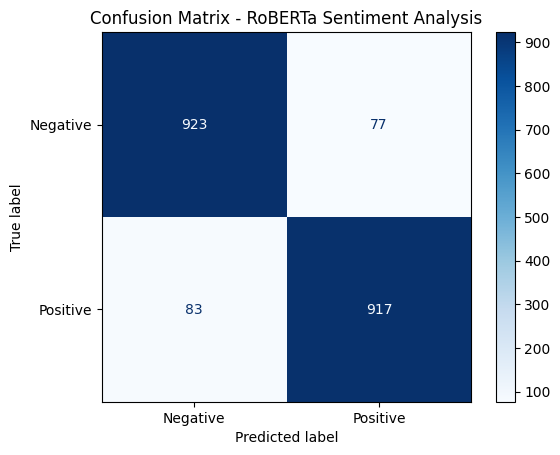

In [30]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [31]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Negative', 'Positive'], digits=4))

	Classification Report for RoBERTa:

               precision    recall  f1-score   support

    Negative     0.9175    0.9230    0.9202      1000
    Positive     0.9225    0.9170    0.9198      1000

   micro avg     0.9200    0.9200    0.9200      2000
   macro avg     0.9200    0.9200    0.9200      2000
weighted avg     0.9200    0.9200    0.9200      2000
 samples avg     0.9200    0.9200    0.9200      2000



In [34]:
tests = [
    "layanannya buruk sekali, bikin emosi",
    "fiturnya sering error dan tidak bisa dipakai",
    "saya sangat kecewa, aplikasinya mengecewakan",
    "respon customer service lama banget",
    "aplikasi makin jelek setelah update terbaru",
    "fitur pembayaran tidak berfungsi, parah",
    "pengalaman paling buruk memakai aplikasi ini",
    "sering crash dan bikin frustasi",
    "tidak puas sama sekali dengan pelayanannya",
    "aplikasinya lemot dan tidak stabil",
    "aplikasinya sangat bagus, mudah digunakan",
    "pelayanan cepat dan memuaskan",
    "fiturnya mantap, sangat membantu aktivitas saya",
    "senang sekali dengan update terbaru, makin keren!",
    "pengalaman yang sangat positif menggunakan aplikasi ini",
    "akhirnya fitur yang saya tunggu keluar juga, keren!",
    "sangat direkomendasikan, praktis dan efisien",
    "interface-nya bagus dan nyaman dipakai",
    "fiturnya lengkap dan berjalan lancar",
    "wah hebat, aplikasinya makin bagus tiap update",
    "aplikasinya biasa saja",
    "fiturnya oke, tapi tidak terlalu istimewa",
    "lumayan, masih banyak yang bisa diperbaiki",
    "pengalaman saya cukup baik, meskipun ada kekurangan",
    "nggak buruk, tapi juga nggak bagus",
    "standar lah, sesuai ekspektasi",
    "saya baru coba sebentar, belum tahu hasilnya",
    "belum banyak fitur, tapi fungsinya jalan",
    "cukup membantu, meski kadang lambat",
    "update terbaru tidak banyak berubah",
    "bodoh"
]

for text in tests:
    label, score = predict_sentiment(text)
    print(f"Teks: {text}")
    print(f"Sentimen: {label}")
    print(f"Probabilitas: {score}")
    print("-" * 50)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Teks: layanannya buruk sekali, bikin emosi
Sentimen: Negatif
Probabilitas: [0.96846414 0.03153587]
--------------------------------------------------
Teks: fiturnya sering error dan tidak bisa dipakai
Sentimen: Negatif
Probabilitas: [0.9773406  0.02265937]
--------------------------------------------------
Teks: saya sangat kecewa, aplikasinya mengecewakan
Sentimen: Negatif
Probabilitas: [0.8896455  0.11035454]
--------------------------------------------------
Teks: respon customer service lama banget
Sentimen: Negatif
Probabilitas: [0.9173544  0.08264564]
--------------------------------------------------
Teks: aplikasi makin jelek setelah update terbaru
Sentimen: Negatif
Probabilitas: [0.9914733  0.00852665]
--------------------------------------------------
Teks: fitur pembayaran tidak berfungsi, parah
Sentimen: Negatif
Probabilitas: [0.98281604 0.01718403]
--------------------------------------------------
Teks: pengalaman paling buruk memakai aplikasi ini
Sentimen: Negatif
Probab

# **Save + Test Predict**

In [35]:
from google.colab import files
import os
import shutil

save_dir = "/content/roberta_save"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "roberta_sentiment_model.h5")
model.save(model_path, include_optimizer=False)
print(f"Model disimpan di: {model_path}")

tokenizer_path = os.path.join(save_dir, "roberta_tokenizer")
tokenizer_roberta_indo.save_pretrained(tokenizer_path)

files.download(model_path)

zip_path = "/content/roberta_tokenizer.zip"
shutil.make_archive("/content/roberta_tokenizer", 'zip', tokenizer_path)
files.download(zip_path)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model disimpan di: /content/roberta_save/roberta_sentiment_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!rm -rf /content/drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
model_path = "/content/roberta_save/roberta_sentiment_model.h5"

model = keras.models.load_model(
    model_path,
    custom_objects={"TFRobertaModel": TFRobertaModel},
    compile=False
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model_1 (TFRobe  TFBaseModelOutputWithPooli   1259781   ['input_ids[0][0]',           
 rtaModel)                   ngAndCrossAttentions(last_   12         'attention_mask[0][0]']      
                             hidden_state=(None, 128, 7                                       

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/SKRIPSI/roberta_tokenizer.zip"
extract_path = "/content/drive/MyDrive/SKRIPSI/roberta_tokenizer"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("done")

done


In [ ]:
extract_path = "/content/roberta_save/roberta_tokenizer"

tokenizer = RobertaTokenizerFast.from_pretrained(extract_path)
print("Tokenizer berhasil diload!")

Tokenizer berhasil diload!


In [ ]:
MAX_LEN = 128